In [ ]:
import numpy as np

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import tensorflow_probability as tfp
tfd = tfp.distributions

from scipy.stats import norm
from scipy.stats import skewnorm
import statsmodels.api as sm

from tqdm.notebook import tqdm
import pickle
import pandas as pd
import os

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
%matplotlib inline

In [ ]:
dtype = 'float32'

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

In [ ]:
from uncertainty import *
from utils import *

## Data

In [ ]:
from PIL import UnidentifiedImageError
from torch.utils.data._utils.collate import default_collate

In [ ]:
import torchvision
import torchvision.transforms as transforms
import random
import pandas as pd
import random
from torch.utils.data import DataLoader, Subset

In [ ]:
classification = True

In [ ]:
transform = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.ToTensor()
])

In [ ]:
n_train = 500
n_test = 500

In [ ]:
# dataset = torchvision.datasets.CelebA(
#     root='./data', split='all', target_type='attr', transform=transform, download=True)

In [ ]:
class SafeCelebADataset(torchvision.datasets.CelebA):
    def __getitem__(self, index):
        try:
            return super().__getitem__(index)
        except (UnidentifiedImageError, FileNotFoundError) as e:
            print(f"Skipping corrupted or missing image at index {index}: {e}")
            return None

In [ ]:
def my_collate(batch):
    # Filter out any samples that are None.
    batch = [item for item in batch if item is not None]
    if len(batch) == 0:
        # Optionally, you could raise an error or return empty tensors.
        raise ValueError("All items in the batch are None")
    return default_collate(batch)

In [ ]:
train_dataset = SafeCelebADataset(
    root='/content/drive/MyDrive/My projects/Uncertainty_under_shift/data',
    split='train',
    target_type='attr',
    transform=transform,
    download=True
)

In [ ]:
blond_hair_idx = train_dataset.attr_names.index('Blond_Hair')
young_idx = train_dataset.attr_names.index('Young')
gray_hair_idx = train_dataset.attr_names.index('Gray_Hair')

In [ ]:
blond_hair_idx, young_idx, gray_hair_idx

(9, 39, 26, 20, 17, 10, 15, 18)

In [ ]:
attribute_idx = pale_idx
y_idx = blond_hair_idx
reverse = False

In [ ]:
def filter_dataset(dataset, desired_attribute_ratio, attribute_idx, reverse=False):
    total = len(dataset)
    if hasattr(dataset, 'attr'):
        attr = dataset.attr
        if hasattr(attr, 'numpy'):
            attr = attr.numpy()
    else:
        raise AttributeError("Dataset does not have an 'attr' property.")

    # Create a boolean mask for attribute hair (assuming 1 indicates attribute)
    if reverse:
        attribute_mask = (attr[:, attribute_idx] == 0)
    else:
        attribute_mask = (attr[:, attribute_idx] == 1)

    # Get indices for attribute and non-attribute samples.
    attribute_indices = np.where(attribute_mask)[0].tolist()
    non_attribute_indices = np.where(~attribute_mask)[0].tolist()

    # Determine desired numbers from each group.
    n_attribute_desired = int(desired_attribute_ratio * total)
    n_non_attribute_desired = total - n_attribute_desired

    n_attribute = min(len(attribute_indices), n_attribute_desired)
    n_non_attribute = min(len(non_attribute_indices), n_non_attribute_desired)

    # Randomly sample from each group and combine.
    random.shuffle(attribute_indices)
    random.shuffle(non_attribute_indices)
    selected_indices = attribute_indices[:n_attribute] + non_attribute_indices[:n_non_attribute]
    random.shuffle(selected_indices)

    return selected_indices

In [ ]:
def filter_existing_indices(dataset, indices, ):
    """
    Given a dataset and a list of indices, return a list of indices
    for which the image file exists.
    """
    valid_indices = []
    image_dir = os.path.join(dataset.root, dataset.base_folder, 'img_align_celeba')

    for i in tqdm(indices):
        file_path = os.path.join(image_dir, dataset.filename[i])
        if os.path.exists(file_path):
            valid_indices.append(i)
    return valid_indices

In [ ]:
# For training, mostly attribute: ~90% attribute, 10% non-attribute.
train_selected = filter_dataset(train_dataset, desired_attribute_ratio=0.9, attribute_idx=attribute_idx, reverse=reverse)
train_selected = filter_existing_indices(train_dataset, train_selected)

  0%|          | 0/78832 [00:00<?, ?it/s]

In [ ]:
train_selected = train_selected[:n_train]

In [ ]:
# For testing, mostly attribute: ~10% attribute, 90% non-attribute.
test_selected = filter_dataset(train_dataset, desired_attribute_ratio=0.1, attribute_idx=attribute_idx, reverse=reverse)
test_selected = filter_existing_indices(train_dataset, test_selected)

  0%|          | 0/116492 [00:00<?, ?it/s]

In [ ]:
test_selected = [a for a in test_selected if a not in train_selected]
test_selected = test_selected[:n_test]

In [ ]:
def create_arrays(dataset, selected_indices, y_idx, batch_size=64, num_workers=2):

    # Create a subset dataset using the selected indices.
    subset = Subset(train_dataset, train_selected)
    loader = DataLoader(subset, batch_size=64, num_workers=2, shuffle=False, collate_fn=my_collate)


    X_list = []
    Y_list = []

    # Iterate through the DataLoader
    for imgs, attrs in tqdm(loader, desc="Loading batches"):
        # Convert the label attribute to binary (assuming attrs is a tensor of shape (batch, 40))
        # Use the already defined index for label
        labels = ((attrs[:, y_idx] + 1) // 2).numpy()  # shape (batch,)
        # If imgs is a tensor, convert to numpy array.
        X_list.append(imgs.numpy())
        Y_list.append(labels)

    # Concatenate batches into full arrays.
    Xs = np.concatenate(X_list, axis=0)
    Ys = np.concatenate(Y_list, axis=0).reshape(-1, 1)
    return Xs, Ys

In [ ]:
# Create train and test arrays.
Xs, Ys = create_arrays(train_dataset, train_selected, y_idx=y_idx, num_workers=2)
print("Training set images shape:", Xs.shape)
print("Training set labels shape:", Ys.shape)

Loading batches:   0%|          | 0/8 [00:00<?, ?it/s]

Training set images shape: (500, 3, 32, 32)
Training set labels shape: (500, 1)


In [ ]:
new_Xs, new_Ys = create_arrays(train_dataset, test_selected, y_idx=y_idx, num_workers=2)
print("Test set images shape:", new_Xs.shape)
print("Test set labels shape:", new_Ys.shape)

Loading batches:   0%|          | 0/8 [00:00<?, ?it/s]

Test set images shape: (500, 3, 32, 32)
Test set labels shape: (500, 1)


#### Embedding $g_\xi$

In [ ]:
representation_dim = 16

In [ ]:
# g = tf.keras.Sequential([tf.keras.layers.InputLayer(shape=(d,), name='encoder_imodel_inputnput'),
#                                tf.keras.layers.Dense(representation_dim, name='l1')])


g = tf.keras.Sequential([
    tf.keras.Input(shape=(32, 32, 3)),
    tf.keras.layers.Conv2D(32, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Conv2D(32, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Flatten(),  # Flatten the tensor to shape (None, 6*6*64)
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(representation_dim)
])

#### Prediction model $f_\theta ∘ g_\xi$

In [ ]:
pred_model = tf.keras.Sequential(list(g.layers) + [tf.keras.layers.Dense(1, use_bias=False)])

pred_optimizer = keras.optimizers.Adam(learning_rate=1e-3)
pred_model.compile(optimizer=pred_optimizer, loss=tf.keras.losses.BinaryCrossentropy(from_logits=True), metrics=['accuracy'])

Train embedding parameters $\xi$ to maximize the likelihood of the training data $(X,Y)$

In [ ]:
tensorflow_Xs, tensorflow_new_Xs = np.moveaxis(Xs, 1, -1), np.moveaxis(new_Xs, 1, -1)

In [ ]:
# train model on X, Y
%%time
history = pred_model.fit(tensorflow_Xs, Ys, epochs=10)

Epoch 1/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.8055 - loss: 0.5636
Epoch 2/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.8154 - loss: 0.4602
Epoch 3/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8077 - loss: 0.4584
Epoch 4/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.8037 - loss: 0.4436
Epoch 5/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8084 - loss: 0.4070
Epoch 6/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8095 - loss: 0.4005
Epoch 7/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8044 - loss: 0.3682
Epoch 8/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8046 - loss: 0.3268
Epoch 9/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8812 - loss: 0.2602
Epoch 10/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8837 - loss: 0.2726
CPU times: user 9.2 s, sys: 674 ms, total: 9.88 s
Wall time: 3.93 s


In [ ]:
vanilla_predictions = np.array(tf.nn.sigmoid(pred_model(tensorflow_new_Xs))).flatten()

In [ ]:
n_bins = 10

In [ ]:
vanilla_acc, vanilla_ece, vanilla_nll, vanilla_entropy, vanilla_avg_p = binary_metrics(new_Ys, vanilla_predictions, n_bins=n_bins)
print("accuracy: %.4f, ECE: %.4f, NLL: %.4f, Entropy: %.4f, Average prediction: %.4f" % (vanilla_acc, vanilla_ece, vanilla_nll, vanilla_entropy, vanilla_avg_p))

accuracy: 0.8760, ECE: 0.1101, NLL: 0.2540, Entropy: 0.2180, Average prediction: 0.1123


### VIDS

Define encoder $h_\gamma$

In [ ]:
#############################################
# Encoder
#############################################

In [ ]:
gXstar_inputs = tf.keras.Input(shape=(representation_dim,), name="gXstar_input")
gX_summary_input = tf.keras.Input(shape=(representation_dim,), name="gX_summary_input")
combined = tf.keras.layers.Concatenate()([gXstar_inputs, gX_summary_input])

gamma_layer = tf.keras.layers.Dense(32 * representation_dim, activation="relu")(combined)
gamma_layer = tf.keras.layers.Dense(16 * representation_dim, activation="relu")(gamma_layer)
gamma_layer = tf.keras.layers.Dense(8 * representation_dim, activation="relu")(gamma_layer)
gamma_layer = tf.keras.layers.Dense(4 * representation_dim, activation="relu")(gamma_layer)
gamma = tf.keras.layers.Dense(2 * representation_dim)(gamma_layer)

h = tf.keras.Model(inputs=[gXstar_inputs, gX_summary_input], outputs=gamma)

Train the encoder $h_\gamma$

In [ ]:
optimizer = tf.keras.optimizers.Adam(learning_rate=1e-3)

In [ ]:
%%time
# h, losses = train_posterior(tensorflow_Xs, Ys, g, h, optimizer, J=10, m=20, n=1000, K=50, tau=0.001, lambda_val=0.005, classification=True)
h, losses = train_posterior(tensorflow_Xs, Ys, g, h, optimizer, J=10, m=20, n=1000, K=50, tau=0.0, lambda_val=0.005, classification=True)

  0%|          | 0/50 [00:00<?, ?it/s]

--- iteration 0, loss 1.4987, split var: 0.1488, train loss: 0.4493, test loss: 1.0935, KL: -16.8476 ---
--- iteration 1, loss 0.7909, split var: 0.0287, train loss: 0.3225, test loss: 0.6473, KL: -16.5782 ---
--- iteration 2, loss 0.7682, split var: 0.0557, train loss: 0.4439, test loss: 0.6351, KL: -17.4523 ---
--- iteration 3, loss 0.7621, split var: 0.0640, train loss: 0.3714, test loss: 0.1865, KL: -16.6101 ---
--- iteration 4, loss 0.6691, split var: 0.0470, train loss: 0.5011, test loss: 0.4763, KL: -16.7596 ---
--- iteration 5, loss 0.6346, split var: 0.0269, train loss: 0.3661, test loss: 0.4422, KL: -17.7511 ---
--- iteration 6, loss 0.6030, split var: 0.0488, train loss: 0.3546, test loss: 0.1519, KL: -16.5095 ---
--- iteration 7, loss 0.4040, split var: 0.0116, train loss: 0.2632, test loss: 0.1778, KL: -17.7417 ---
--- iteration 8, loss 0.4460, split var: 0.0610, train loss: 0.2194, test loss: 0.3812, KL: -17.6987 ---
--- iteration 9, loss 0.4142, split var: 0.0126, train 

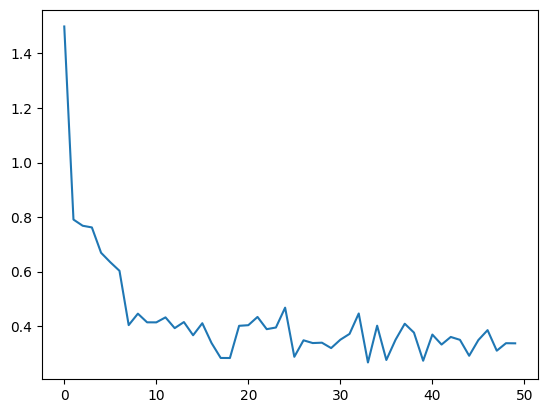

In [ ]:
plt.plot(np.array(losses));

Learned posterior

In [ ]:
use_sampling = True

In [ ]:
# embeddings
gX = g(tensorflow_Xs)
gXstar = g(tensorflow_new_Xs[0:n_test])

posterior_mus, posterior_sigmas =  get_phi(h, gX, gXstar)

# evaluate uncertainty for x*
if use_sampling:
  n_samples_for_avg = 1000
  preds = []
  for i in tqdm(range(n_samples_for_avg)):
    # samples from learned posterior
    epsilon = tf.random.normal(shape=posterior_mus.shape)
    theta_samples =  posterior_mus + epsilon * posterior_sigmas
    # prediction with sampled theta
    fXstar = tf.reduce_sum(theta_samples * gXstar, axis=-1)
    preds.append(tf.nn.sigmoid(fXstar))
  variational_predictions = np.array(preds)
  variational_certainties = np.mean(preds, axis=0)
else:
  variational_predictions = tf.reduce_sum(posterior_mus * gXstar, axis=-1).numpy()
  variational_certainties = variational_predictions

  0%|          | 0/1000 [00:00<?, ?it/s]

In [ ]:
variational_acc, variational_ece, variational_nll, variational_entropy, variational_avg_p = binary_metrics(new_Ys[0:n_test], variational_certainties.reshape(-1,1), n_bins=n_bins)
print("accuracy: %.4f, ECE: %.4f, NLL: %.4f, Entropy: %.4f, Average prediction: %.4f" % (variational_acc, variational_ece, variational_nll, variational_entropy, variational_avg_p))

accuracy: 0.9380, ECE: 0.0523, NLL: 0.1771, Entropy: 0.2004, Average prediction: 0.1925
